<a href="https://colab.research.google.com/github/sonuyadav-sys/CLIMATE-CONDITION-PREDICTION/blob/main/Climate%20condition%20analysis%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Accuracy for Sonu Yadav (Roll 25SCS1003003631): 98.00%


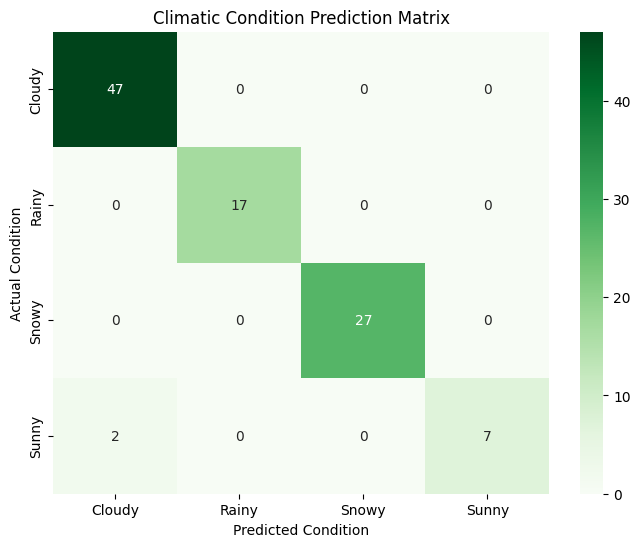

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. GENERATING CLIMATIC DATASET
np.random.seed(42)
data_size = 500
data = {
    'Temperature': np.random.uniform(-10, 45, data_size),
    'Humidity': np.random.uniform(20, 100, data_size),
    'Wind_Speed': np.random.uniform(0, 40, data_size),
    'Pressure': np.random.uniform(990, 1030, data_size)
}
df = pd.DataFrame(data)

# Defining Weather Type logic (Target Variable)
def label_weather(row):
    if row['Temperature'] > 30 and row['Humidity'] < 50: return 'Sunny'
    if row['Temperature'] < 5: return 'Snowy'
    if row['Humidity'] > 75: return 'Rainy'
    return 'Cloudy'

df['Weather_Type'] = df.apply(label_weather, axis=1)

# 2. PREPARING DATA
X = df[['Temperature', 'Humidity', 'Wind_Speed', 'Pressure']]
y = df['Weather_Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAINING MODEL (Random Forest)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 4. RESULTS
y_pred = model.predict(X_test)
print(f"Project Accuracy for Sonu Yadav (Roll 25SCS1003003631): {accuracy_score(y_test, y_pred)*100:.2f}%")

# 5. VISUALIZATION (Confusion Matrix)
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Climatic Condition Prediction Matrix')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()